<a href="https://colab.research.google.com/github/KyleFranzR/CPE-313/blob/main/Rodriguez_Hands-on-Activity-8.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Activity 5.2 Topic Modeling

#### Objective(s):

This activity aims to introduce how to use LDA for topic modeling

#### Intended Learning Outcomes (ILOs):
* Demonstrate how to preprocess words in the dataset.
* Demonstrate how to create and build LDA model using specified number of topics

#### Resources:
* Jupyter Notebook
* fetch20 dataset

## Procedures
Load the necessary libraries and datasets

Remove the headers, footers, and quotes from each member of the set

### Building a logistic model

In [ ]:
import nltk
import pandas as pd
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)
import numpy as np
import os
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from __future__ import division
%matplotlib inline
from sklearn import datasets
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [ ]:
data = pd.read_csv('/content/reviews_data.csv')[['Rating', 'Review']]
data.head()

,Rating,Review
0,5.0,Amber and LaDonna at the Starbucks on Southwes...
1,5.0,** at the Starbucks by the fire station on 436...
2,5.0,I just wanted to go out of my way to recognize...
3,5.0,Me and my friend were at Starbucks and my card...
4,5.0,I’m on this kick of drinking 5 cups of warm wa...


In [ ]:
# Remove 3 star reviews
data = data[data.Rating!=3]

# Set 4/5 star reviews to positive, the rest to negative
data['sentiment'] = np.where(data['Rating'] >= 4, 'positive', 'negative')

# Include only the sentiment and reviews columns
data = data[['sentiment', 'Review']]
data.head()

,sentiment,Review
0,positive,Amber and LaDonna at the Starbucks on Southwes...
1,positive,** at the Starbucks by the fire station on 436...
2,positive,I just wanted to go out of my way to recognize...
3,positive,Me and my friend were at Starbucks and my card...
4,positive,I’m on this kick of drinking 5 cups of warm wa...


In [ ]:
# Text preprocessing steps - remove numbers, captial letters and punctuation

alphanumeric = lambda x: re.sub(r"""\w*\d\w*""", ' ', x)
punc_lower = lambda x: re.sub('[%s]' % re.escape(string.punctuation), ' ', x.lower())

data['Review'] = data.Review.map(alphanumeric).map(punc_lower)
data.head()

,sentiment,Review
0,positive,amber and ladonna at the starbucks on southwes...
1,positive,at the starbucks by the fire station on i...
2,positive,i just wanted to go out of my way to recognize...
3,positive,me and my friend were at starbucks and my card...
4,positive,i’m on this kick of drinking cups of warm wa...


In [ ]:
# Split the data into X and y data sets
X = data.Review
y = data.sentiment

In [ ]:
# Split the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape, y_train.shape

((571,), (571,))

In [ ]:
X_test.shape, y_test.shape

((246,), (246,))

In [ ]:
# The first document-term matrix has default Count Vectorizer values - counts of unigrams

cv1 = CountVectorizer(stop_words='english')

X_train_cv1 = cv1.fit_transform(X_train)
X_test_cv1  = cv1.transform(X_test)

print(X_train_cv1.toarray().shape)

(571, 4365)


In [ ]:
# Create a logistic regression model to use

lr = LogisticRegression()

In [ ]:
# Train the first model
lr.fit(X_train_cv1, y_train)
y_pred_cv1 = lr.predict(X_test_cv1)

In [ ]:
# Create a function to calculate the error metrics, since we'll be doing this several times

def conf_matrix(actual, predicted):
    cm = confusion_matrix(actual, predicted)
    sns.heatmap(cm, xticklabels=['predicted_negative', 'predicted_positive'],
                yticklabels=['actual_negative', 'actual_positive'], annot=True,
                fmt='d', annot_kws={'fontsize':20}, cmap="YlGnBu");

    true_neg, false_pos = cm[0]
    false_neg, true_pos = cm[1]

    a = true_pos + true_neg
    b = true_pos + true_neg + false_pos + false_neg
    print (a/b)

    accuracy = round(float((true_pos + true_neg) / (true_pos + true_neg + false_pos + false_neg)),3)
    precision = round(float((true_pos) / (true_pos + false_pos)),3)
    recall = round(float((true_pos) / (true_pos + false_neg)),3)
    f1 = round(float(2 * (precision * recall) / (precision + recall)),3)

    cm_results = [accuracy, precision, recall, f1]
    return cm_results

0.9308943089430894


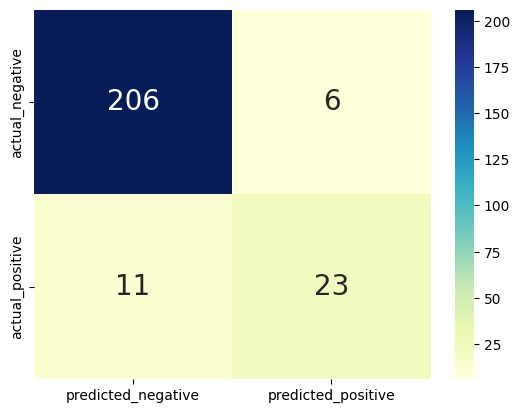

In [ ]:
# The heat map for the first logistic regression model
cm1 = conf_matrix(y_test, y_pred_cv1)

### Latent Dirichlet Allocation and Topic Modeling

In [ ]:
categories = ['alt.atheism', 'comp.graphics', 'rec.sport.baseball']
ng_train = datasets.fetch_20newsgroups(subset='train',
                                       categories=categories,
                                       remove=('headers',
                                               'footers', 'quotes'))

In [ ]:
print(ng_train.data[2])
print("++\n", ng_train.data[1504])
print("++\n", ng_train.data[1000])



	Sorry, I was, but I somehow have misplaced my diskette from the last 
couple of months or so. However, thanks to the efforts of Bobby, it is being 
replenished rather quickly!  

	Here is a recent favorite:

	--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "

        S.N. Mozumder (snm6394@ultb.isc.rit.edu) 


--


       "Satan and the Angels do not have freewill.  
        They do what god tells them to do. "
++
 

Why not use the PD C library for reading/writing TIFF files? It took me a
good 20 minutes to start using them in your own app.

Martin

--
---------------------------------------------------------------------------
++
 
Indeed, if the color teal on a team's uniforms is any indication of the
future, the Marlins are in dire trouble! Refer to the San Jose Sharks for
proof... But I have hope for the Marlins. I was a sometime member of the
Rene Lachemann fan club at the Oakland Coliseum, and have a deep respect
for the guy

* Pre-process all words in your document, including removing stop words.
* Remove words that show up in more than 60% of the documents/
* Vectorize your documents using NGrams

In [ ]:
count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(ng_train.data)

* Create an LDA model with 3 topics. You can do this with GenSim or SkLearn.
* Print out the topics and the 20 words most associated with that topic.
* Try using more or less topics, is there a sweet spot that allows us to separate out the three input classes?
* Find a document that is clearly about baseball, does the model choose it as dominantly the topic?
* Use pyLDAvis (pip install pyldavis) to create an interactive visualization of the topics

In [ ]:
n_topics = 4
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)
data[0]

array([0.00246896, 0.00251041, 0.99253159, 0.00248904])

In [ ]:
print(ng_train.data[0]) # 99% composed of topic 3!




I happen to be a big fan of Jayson Stark.  He is a baseball writer for the 
Philadelphia Inquirer.  Every tuesday he writes a "Week in Review" column.  
He writes about unusual situations that occured during the week.  Unusual
stats.  He has a section called "Kinerisms of the Week" which are stupid
lines by Mets brodcaster Ralph Kiner.  Every year he has the LGTGAH contest.
That stands for "Last guy to get a hit."  He also writes for Baseball 
America.  That column is sort of a highlights of "Week in Review."  If you 
can, check his column out sometime.  He might make you laugh.

Rob Koffler



In [ ]:
def display_topics(model, feature_names, no_top_words):
    for ix, topic in enumerate(model.components_):
        print("Topic ", ix)
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda,count_vectorizer.get_feature_names_out(),20)

Topic  0
jesus matthew said people den col prophecy int away war men messiah den den radius prophet row isaiah psalm row col sea
Topic  1
don god people does just think know like jpeg atheism say image time good believe way use atheists file religion
Topic  2
year game good team think don just games like players better runs hit won league time baseball season win pitching
Topic  3
graphics image edu data mail software ftp pub available send images package computer information use files thanks program processing code


* Open a new dataset from dap_split.txt
* Split this raw file into a set of documents. There is a clear marker between each article.
* Clean the text data and prepare for modeling (note that each document has some <XYZ> tags as well as extra spaces)

In [ ]:
with open('ap.txt','r') as f:
    raw_text = f.read()
docs = raw_text.split('---')
docs[1]

"\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP901021-0008 </DOCNO>\n<TEXT>\n Here are the winning numbers picked Saturday night for the California Lottery's twice-weekly ``Lotto 6-53'' game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.\n </TEXT>\n</DOC>\n<DOC>\n<DOCNO> AP900518-0012 </DOCNO>\n<TEXT>\n A three-judge federal panel on Thursday upheld the authority of the U.S. Army Corps of Engineers to determine the level of discharges from a Missouri River reservoir in South Dakota and North Dakota. The 8th U.S. Circuit Court of Appeals panel overturned a lower court order that releases from the Oahe reservoir be reduced, as had been requested by the drought-stricken states. The appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. In a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. The tug-of-war over water rights pitted the corps and the states of Iowa, Nebraska, Kansas and Missou

In [ ]:
match = re.compile("<[^>]*>").search
for i,doc in enumerate(docs):
    final = []
    temp = doc.split('\n')
    for line in temp:
        if not match(line):
            final.append(line)
    docs[i] = ' '.join(final).strip().lower().replace("`","").replace("'","")
docs[1]

'here are the winning numbers picked saturday night for the california lotterys twice-weekly lotto 6-53 game: 9, 38, 6, 29, 7, 20, and the bonus number, 27.  a three-judge federal panel on thursday upheld the authority of the u.s. army corps of engineers to determine the level of discharges from a missouri river reservoir in south dakota and north dakota. the 8th u.s. circuit court of appeals panel overturned a lower court order that releases from the oahe reservoir be reduced, as had been requested by the drought-stricken states. the appeals panel said it had serious reservations about whether courts have jurisdiction over such decisions by the corps. in a brief order, the panel said it would spell out its legal reasoning later in a formal opinion. the tug-of-war over water rights pitted the corps and the states of iowa, nebraska, kansas and missouri against north dakota, south dakota and montana over whether water flow should be reduced from the reservoir, which stretches from pierre

In [ ]:
print(len(docs))

37


Do LDA modeling to find topics in this chain of articles. Try many different numbers of topics and processing techniques.

In [ ]:
count_vectorizer = CountVectorizer(ngram_range=(1, 3),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

X = count_vectorizer.fit_transform(docs)

In [ ]:
n_topics = 25
n_iter = 10
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                               learning_method='online')
data = lda.fit_transform(X)

In [ ]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))
display_topics(lda,count_vectorizer.get_feature_names_out(),20) # We have to look at the topics before hand and then add the labels afterwards


Topic  0
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic  2
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic  4
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic  5
people, year, million, percent, government, time, police, states, thursday, state, today, soviet, officials, years, city, billion, 

In [ ]:
tn = ["Political Media",None,"Financials",None,"Nordstrom Scandal","Oil","Hurricanes","North Korea","NASA","US Politics","TV Networks","Forest Fires",
      None,"Agriculture/Drought","Middle East","US Political Campaigns","Pollution","Carribean","Health/Medical","Theatre/Arts","Global Warming",
      "Advertisements","Southern US Weather","South America",None]
display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=tn)


Topic: ' Political Media '
percent, million, year, government, people, state, states, soviet, years, court, day, tuesday, american, billion, news, company, police, did, officials, national

Topic  1
year, stormie, percent, government, state, people, years, police, soviet, time, national, million, states, stormie jones, told, officials, billion, new york, wednesday, court

Topic: ' Financials '
year, people, percent, state, government, million, soviet, years, police, states, house, officials, time, today, told, say, day, report, week, company

Topic  3
year, percent, government, states, million, years, time, national, soviet, police, billion, people, week, federal, day, officials, state, thursday, group, court

Topic: ' Nordstrom Scandal '
people, year, percent, soviet, years, million, day, government, time, state, federal, officials, court, police, south, states, billion, american, market, union

Topic: ' Oil '
people, year, million, percent, government, time, police, states, thursday

## Supplementary Activity

* Use your own dataset
* Perform preprocessing of words in the dataset
* Create LDA model using a specified number of topics

In [149]:
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

### Use your own dataset

Dataset source:
> https://www.kaggle.com/datasets/vstepanenko/disaster-tweets

In [237]:
import pandas as pd

data = pd.read_csv('/content/tweets.csv').text

In [238]:
data = data.drop_duplicates()

In [239]:
pd.set_option('display.max_colwidth', None)

In [240]:
data.info()

<class 'pandas.core.series.Series'>
Index: 11223 entries, 0 to 11369
Series name: text
Non-Null Count  Dtype 
--------------  ----- 
11223 non-null  object
dtypes: object(1)
memory usage: 175.4+ KB


In [241]:
data.head()

,text
0,"Communal violence in Bhainsa, Telangana. ""Stones were pelted on Muslims' houses and some houses and vehicles were set ablaze…"
1,"Telangana: Section 144 has been imposed in Bhainsa from January 13 to 15, after clash erupted between two groups on January 12. Po…"
2,Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI
3,Arsonist sets cars ablaze at dealership https://t.co/0gL7NUCPlb https://t.co/u1CcBhOWh9
4,"""Lord Jesus, your love brings freedom and pardon. Fill me with your Holy Spirit and set my heart ablaze with your l… https://t.co/VlTznnPNi8"


### Perform processing of words

In [242]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

data_cv = count_vectorizer.fit_transform(data)

In [243]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2),
                                   stop_words='english',
                                   token_pattern="\\b[a-z][a-z]+\\b",
                                   lowercase=True,
                                   max_df = 0.6)

data_tfidf = tfidf_vectorizer.fit_transform(data)

### Create LDA model

In [244]:
# with CountVectorizer

from sklearn.decomposition import LatentDirichletAllocation
n_topics = 5
n_iter = 20

lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                            learning_method='online')
data_lda = lda.fit_transform(data_cv)
data_lda[5]

array([0.01000678, 0.01003162, 0.01000508, 0.95994936, 0.01000716])

In [246]:
# with TF-IDF

n_topics = 5
n_iter = 20

lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=n_iter,
                                random_state=42,
                            learning_method='online')
data_lda_tfidf = lda.fit_transform(data_tfidf)
data_lda_tfidf[5]

array([0.03781707, 0.0381361 , 0.03784999, 0.84803971, 0.03815714])

In [247]:
def display_topics(model, feature_names, no_top_words, topic_names=None):
    for ix, topic in enumerate(model.components_):
        if not topic_names or not topic_names[ix]:
            print("\nTopic ", ix)
        else:
            print("\nTopic: '",topic_names[ix],"'")
        print(", ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

In [260]:
# Just some topics I can think of
# I can't think of anything that appropriately describes the words shown here

topics = ['1st Topic', '2nd Topic', '3rd Topic', '4th Topic', '5th Topic']

display_topics(lda,count_vectorizer.get_feature_names_out(),20,topic_names=topics)


Topic: ' 1st Topic '
https, iran, amp, people, bus, sinkhole, like, years, news, china, police, road, just, emergency, time, swallows, old, collision, air, iranian

Topic: ' 2nd Topic '
https, just, body, like, don, know, let, going, think, heart, mass, people, amp, did, upheaval, schools, party, years, time, gove

Topic: ' 3rd Topic '
https, nuclear, drowning, disaster, screaming, puerto, nuclear disaster, puerto rico, rico, obliterate, need, amp, screams, started, demolition, wounds, demolish, middle, like, looks

Topic: ' 4th Topic '
https, people, taal, like, volcano, amp, just, climate, taal volcano, don, eruption, want, love, change, time, thunderstorm, warning, need, really, ve

Topic: ' 5th Topic '
https, storm, hazard, stretcher, people, rain, fatality, train, force, wave, heat, heat wave, suicide, bomb, hitchin, new, quarantined, fires, today, violent


> #### ***I trained the LDA model with both count and tf-idf vectorizer***

### Recommendation

In [249]:
from sklearn.neighbors import NearestNeighbors

def get_recommendations(first_article, model, vectorizer, training_vectors):
    new_vec = model.transform(
        vectorizer.transform([first_article]))
    nn = NearestNeighbors(n_neighbors=10, metric='cosine', algorithm='brute')
    nn.fit(training_vectors)
    results = nn.kneighbors(new_vec)
    return results[1][0]

def print_recommendations(first_article,recommend_list):
    print(first_article)
    print('\n------\n')
    for resp in recommend_list:
        print(f'\nRelated comment from data[{resp}]:\n')
        print(f" -->> {data[resp]}")

In [261]:
rec_list = get_recommendations(data[2], lda, count_vectorizer, data_lda)
print_recommendations(data[2], rec_list)

Arsonist sets cars ablaze at dealership https://t.co/gOQvyJbpVI

------


Related comment from data[3898]:

 -->> As far as 'net' gain is cencerned, it is ONCE AGAIN valuing teresapien life as simply capital. You would not destro… https://t.co/bQNN1v61kq

Related comment from data[7982]:

 -->> 3. Influenza in Malaysia is under control. Always take preventive measures. 4. KKM launched Speak out: Express Your Righ…

Related comment from data[551]:

 -->> The Fake News Media and their Democrat Partners are working hard to determine whether or not the future attack by terr…

Related comment from data[9962]:

 -->> Did you know that, Violence against women unabated despite laws &amp; polices to protect victims &amp; survivors.

Related comment from data[8125]:

 -->> Can we appreciate how cute he was when he was panicking 🥺🥺🥺 https://t.co/wC9Q7bvZue

Related comment from data[3697]:

 -->> My favorite type of American is the one who swears they hate Trump, like so much you cant even joke a

> #### ***We are basically using the created LDA model to recommend a related topic for the text that we input using nearest neighbor search.***

### Aditional Instructions for evaluation
- Show at least 2 examples of datapoints for each topic
- (Optional) Plot the clustering of topics using KMeans, TSNE using a Scatter Plot

In [262]:
# show 2 datapoint samples for each topic

for i, topic in enumerate(topics):
    print(f"Topic: {topic}\n")
    top_indices = np.argsort(data_lda[:, i])[-2:]

    for idx in reversed(top_indices):
        confidence = data_lda[idx][i]
        print(f"-->> Sample: {data[idx][:200]}...")
        print(f"-->> Confidence: {confidence:.2%}")
        print("-" * 20)
    print("\n")

Topic: 1st Topic

-->> Sample: can we create an anti-bioterrorism commission?...
-->> Confidence: 97.64%
--------------------
-->> Sample: Human remains found in bag in Dublin estate via https://t.co/o3L2YgR4uC...
-->> Confidence: 97.64%
--------------------


Topic: 2nd Topic

-->> Sample: All national security experts, anti terrorism journos are silent on arrest of Devender Singh while ferrying 2 wanted Hizbul…...
-->> Confidence: 97.32%
--------------------
-->> Sample: Why is this more important, you ask? Because he needs the military to be on his side. Self-interest above all nga eh. Is…...
-->> Confidence: 97.28%
--------------------


Topic: 3rd Topic

-->> Sample: Pakistan harbored Terrorist Bin Laden. You’re corrupt, impoverished, and a bligh… https://t.co/WCUoENShDY...
-->> Confidence: 97.89%
--------------------
-->> Sample: #USDJPY despite Richter Scale overbought, Fxstreet Line Up Swissquote bullish long, Jason Sen Mr. Ambulance Chaser B…...
-->> Confidence: 97.49%
-------

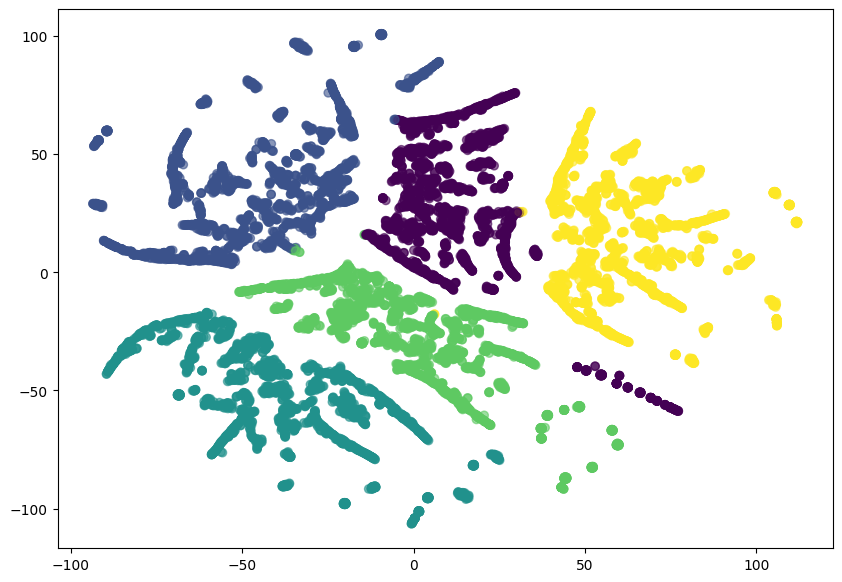

In [252]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
%matplotlib inline


kmeans = KMeans(n_clusters=n_topics, random_state=42)
clusters = kmeans.fit_predict(data_lda)
tsne = TSNE(n_components=2, random_state=42).fit_transform(data_lda)

plt.figure(figsize=(10, 7))
plt.scatter(tsne[:, 0], tsne[:, 1], c=clusters, cmap='viridis', alpha=0.6);

> ***The plot shows that each topic was clustered appropriately***

## Conclusion

> ***This activity introduced me to the concept of topic modelling which is an unsupervised machine learning for clustering several words to a topic. In this activity, we used Latent Dirichlet Allocation as the topic modelling model. For the supplementary activity, I tried using the two vectorizers that we used in the previous activity for the training. I am not really sure how to check whether the model performs well or not, but I think the scatter plot of the clustering shows that the model is performing well. Overall, I was able to demonstrate how to create and train LDA model for topic modelling.***